# Resp Metrics - Example Usage

This notebook demonstrates how to:
1. Load a LabChart text export using labchart_parser
2. Extract cycles based on INSPI/EXPI comments
3. Compute ventilatory metrics for spontaneous breathing
4. Compute mechanical ventilation metrics
5. Use the high-level API for both spontaneous and mechanical ventilation

## Setup and Imports

In [34]:
import sys
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# Import resp_metrics modules
from labchart_parser import LabChartFile
from resp_metrics import (
    cycles_from_comments,
    ventilatory_from_cycles, 
    mechanical_from_cycles,
    compute_from_labchart
)

## 1. Load LabChart Files

In [35]:
# Define file paths (use Path for cross-platform compatibility)
from pathlib import Path

# Get the directory where the notebook is located
notebook_dir = Path(".").resolve()
# Navigate to project root if we're in examples folder
if notebook_dir.name == "examples":
    project_root = notebook_dir.parent
else:
    project_root = notebook_dir

data_dir = project_root / "examples" / "data"
path_spontaneous = str(data_dir / "labchart_file_vs.example.txt")
path_mechanical = str(data_dir / "labchart_file.example.txt")

print(f"Looking for files in: {data_dir}")
print(f"Spontaneous file exists: {Path(path_spontaneous).exists()}")
print(f"Mechanical file exists: {Path(path_mechanical).exists()}")

# Load spontaneous breathing file
lc_spont = LabChartFile.from_file(path_spontaneous)
print("\n=== Spontaneous Breathing File ===")
print("Metadata:", lc_spont.metadata)
print("Channels:", lc_spont.channels)
print("Comments preview:")
print(lc_spont.comments.head())

# Load mechanical ventilation file
lc_mech = LabChartFile.from_file(path_mechanical)
print("\n=== Mechanical Ventilation File ===")
print("Metadata:", lc_mech.metadata)
print("Channels:", lc_mech.channels)
print("Comments preview:")
print(lc_mech.comments.head())


Looking for files in: /Users/damienbachasson/GitHub_repos/resp_metrics/examples/data
Spontaneous file exists: True
Mechanical file exists: True

=== Spontaneous Breathing File ===
Metadata: {'Interval': '0.0001 s', 'ExcelDateTime': '4.4725490703932366e+04\t06/13/22 11:46:36.819757', 'TimeFormat': 'StartOfBlock', 'DateFormat': '', 'UnitName': ['L/s', '*'], 'Interval_s': 0.0001, 'blocks': [{'Interval': '0.0001 s', 'ExcelDateTime': '4.4725490703932366e+04\t06/13/22 11:46:36.819757', 'TimeFormat': 'StartOfBlock', 'DateFormat': '', 'ChannelTitle': ['Flow', 'Pressure'], 'Range': ['200.0 mV', '1.55 cmH2O'], 'UnitName': ['L/s', '*'], 'TopValue': ['2.56', '*'], 'BottomValue': ['-2.48', '*'], 'Interval_s': 0.0001}]}
Channels: ['Flow', 'Pressure']
Comments preview:
   Time  time_block  time_abs  block Comment
0  2.64        3.59      3.59      1   INSPI
1  4.00        4.95      4.95      1    EXPI
2  6.20        7.15      7.15      1   INSPI
3  7.54        8.49      8.49      1    EXPI
4  9.86   

## 2. Extract Respiratory Cycles

In [36]:
# Extract cycles from spontaneous breathing data
cycles_spont = cycles_from_comments(
    lc_spont.comments,
    block=1,
    insp_label="INSPI",
    expi_label="EXPI"
)

print("=== Spontaneous Breathing Cycles ===")
print(f"Number of cycles detected: {len(cycles_spont)}")
print(cycles_spont.head(10))

# Extract cycles from mechanical ventilation data
cycles_mech = cycles_from_comments(
    lc_mech.comments,
    block=1,
    insp_label="INSPI",
    expi_label="EXPI"
)

print("=== Mechanical Ventilation Cycles ===")
print(f"Number of cycles detected: {len(cycles_mech)}")
print(cycles_mech.head(10))


=== Spontaneous Breathing Cycles ===
Number of cycles detected: 11
  block_name  block  n_cycle  t_inspi  t_expi  t_next_inspi
0    Block 1      1        1     3.59    4.95          7.15
1    Block 1      1        2     7.15    8.49         10.81
2    Block 1      1        3    10.81   12.13         14.33
3    Block 1      1        4    14.33   15.65         18.01
4    Block 1      1        5    18.01   19.31         21.75
5    Block 1      1        6    21.75   22.97         25.45
6    Block 1      1        7    25.45   26.95         29.19
7    Block 1      1        8    29.19   30.43         32.21
8    Block 1      1        9    32.21   33.67         35.71
9    Block 1      1       10    35.71   37.27         39.39
=== Mechanical Ventilation Cycles ===
Number of cycles detected: 24
  block_name  block  n_cycle  t_inspi  t_expi  t_next_inspi
0    Block 1      1        1     1.93    2.41          4.24
1    Block 1      1        2     4.24    4.72          6.55
2    Block 1      1      

## 3. Compute Ventilatory Metrics

In [37]:
# Compute ventilatory metrics for spontaneous breathing
# Note: pes_col is required for WOB calculation (Work of Breathing)
# If esophageal pressure (Pes) is not available, WOB will be NaN
metrics_spont = ventilatory_from_cycles(
    lc_spont.get_block_df(1),
    cycles_spont,
    flow_col="Flow",
    volume_col=None,
    pressure_col="Pressure",
    pes_col=None,  # Set to "Pes" if esophageal pressure available for WOB
    flow_unit="L/s"
)

print("=== Spontaneous Breathing Metrics ===")
print(metrics_spont.head())
print("\nSummary statistics:")
print(metrics_spont[['Ti', 'Te', 'Ttot', 'BF', 'VT', 'VE']].describe())

=== Spontaneous Breathing Metrics ===
  block_name  block  n_cycle  t_inspi  t_expi    Ti  Ttot    Te         BF  \
0    Block 1      1        1     3.59    4.95  1.36  3.56  2.20  16.853933   
1    Block 1      1        2     7.15    8.49  1.34  3.66  2.32  16.393443   
2    Block 1      1        3    10.81   12.13  1.32  3.52  2.20  17.045455   
3    Block 1      1        4    14.33   15.65  1.32  3.68  2.36  16.304348   
4    Block 1      1        5    18.01   19.31  1.30  3.74  2.44  16.042781   

         VT        VE       PIF       PEF        IE  WOB       PTP  
0  0.324833  5.474709  0.333593  0.270529  0.618182  NaN  2.402572  
1  0.326351  5.350013  0.333653  0.262960  0.577586  NaN  1.969047  
2  0.306984  5.232688  0.322686  0.255432  0.600000  NaN  1.660348  
3  0.315760  5.148261  0.324232  0.288983  0.559322  NaN  1.753630  
4  0.332073  5.327367  0.346734  0.292243  0.532787  NaN  2.141955  

Summary statistics:
              Ti         Te       Ttot         BF         

## 4. Compute Mechanical Ventilation Metrics

In [38]:
# Compute mechanical ventilation metrics
# Note: flow_unit specifies the unit of flow data for correct VT calculation
metrics_mech = mechanical_from_cycles(
    lc_mech.get_block_df(1),
    cycles_mech,
    flow_col="Flow",
    volume_col=None,
    pressure_col="Pressure",
    flow_unit="L/min"  # Specify flow unit for correct VT calculation
)

print("=== Mechanical Ventilation Metrics ===")
print(metrics_mech.head())
print("\nSummary statistics:")
print(metrics_mech[['Ti', 'Te', 'Ttot', 'BF', 'VT', 'VE', 'PEEP', 'Ppeak']].describe())

=== Mechanical Ventilation Metrics ===
  block_name  block  n_cycle  t_inspi  t_expi    Ti  Ttot    Te         BF  \
0    Block 1      1        1     1.93    2.41  0.48  2.31  1.83  25.974026   
1    Block 1      1        2     4.24    4.72  0.48  2.31  1.83  25.974026   
2    Block 1      1        3     6.55    7.02  0.47  2.30  1.83  26.086957   
3    Block 1      1        4     8.85    9.33  0.48  2.31  1.83  25.974026   
4    Block 1      1        5    11.16   11.64  0.48  2.30  1.82  26.086957   

         VT  ...       PEF        IE       PEEP     Ppeak  Pplat         dP  \
0  0.400350  ...  0.897405  0.262295  10.460430  49.19904    NaN  38.738610   
1  0.395744  ...  0.922424  0.262295  10.573840  49.02486    NaN  38.451020   
2  0.396687  ...  0.946802  0.256831  10.570075  49.52754    NaN  38.957465   
3  0.395101  ...  0.960446  0.262295  10.556005  49.78465    NaN  39.228645   
4  0.396366  ...  0.935614  0.263736  10.504840  50.21294    NaN  39.708100   

   dP_fallback  C

## 5. Visualization

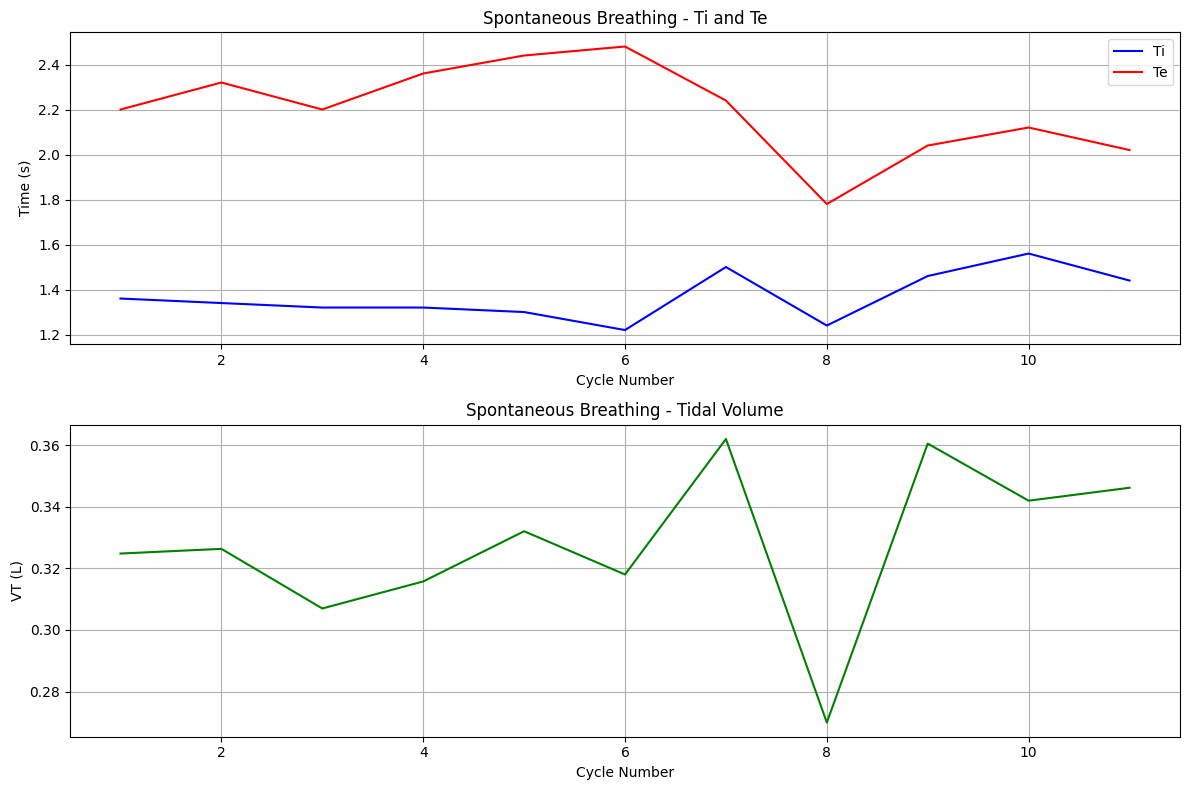

In [39]:
# Plot respiratory cycle timing comparison
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Spontaneous breathing
axes[0].plot(metrics_spont['n_cycle'], metrics_spont['Ti'], 'b-', label='Ti')
axes[0].plot(metrics_spont['n_cycle'], metrics_spont['Te'], 'r-', label='Te')
axes[0].set_title('Spontaneous Breathing - Ti and Te')
axes[0].set_xlabel('Cycle Number')
axes[0].set_ylabel('Time (s)')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(metrics_spont['n_cycle'], metrics_spont['VT'], 'g-')
axes[1].set_title('Spontaneous Breathing - Tidal Volume')
axes[1].set_xlabel('Cycle Number')
axes[1].set_ylabel('VT (L)')
axes[1].grid(True)

plt.tight_layout()
plt.show()


## 6. High-Level API Usage

In [40]:
# High-level API for spontaneous breathing
# Note: pes_col can be specified for WOB calculation
# Outputs are saved to the output/ directory
output_dir = Path("output")
output_dir.mkdir(exist_ok=True)

result_spont = compute_from_labchart(
    path_spontaneous,
    block=1,
    flow_col="Flow",
    flow_unit="L/s",
    volume_col=None,
    pressure_col="Pressure",
    pes_col=None,  # Set to "Pes" if esophageal pressure available for WOB
    mechanically_ventilated=False,
    output_dir=output_dir,
    output_prefix="spontaneous",
)

print("=== High-Level API: Spontaneous Breathing ===")
print("Cycles:")
print(result_spont["cycles"].head())
print("\nVentilatory metrics:")
print(result_spont["ventilatory"].head())
print(f"\nVentilator metrics available: {result_spont['ventilator'] is not None}")


=== High-Level API: Spontaneous Breathing ===
Cycles:
  block_name  block  n_cycle  t_inspi  t_expi  t_next_inspi
0    Block 1      1        1     3.59    4.95          7.15
1    Block 1      1        2     7.15    8.49         10.81
2    Block 1      1        3    10.81   12.13         14.33
3    Block 1      1        4    14.33   15.65         18.01
4    Block 1      1        5    18.01   19.31         21.75

Ventilatory metrics:
  block_name  block  n_cycle  t_inspi  t_expi    Ti  Ttot    Te         BF  \
0    Block 1      1        1     3.59    4.95  1.36  3.56  2.20  16.853933   
1    Block 1      1        2     7.15    8.49  1.34  3.66  2.32  16.393443   
2    Block 1      1        3    10.81   12.13  1.32  3.52  2.20  17.045455   
3    Block 1      1        4    14.33   15.65  1.32  3.68  2.36  16.304348   
4    Block 1      1        5    18.01   19.31  1.30  3.74  2.44  16.042781   

         VT        VE       PIF       PEF        IE  WOB       PTP  
0  0.324833  5.474709  0.3

In [41]:
# High-level API for mechanical ventilation
result_mech = compute_from_labchart(
    path_mechanical,
    block=1,
    flow_col="Flow",
    flow_unit="L/min",
    volume_col=None,
    pressure_col="Pressure",
    mechanically_ventilated=True,
    output_dir=output_dir,
    output_prefix="mechanical",
)

print("=== High-Level API: Mechanical Ventilation ===")
print("Cycles:")
print(result_mech["cycles"].head())
print("\nVentilatory metrics:")
print(result_mech["ventilatory"].head())
print("\nVentilator mechanics:")
if result_mech["ventilator"] is not None:
    print(result_mech["ventilator"].head())
else:
    print("No ventilator metrics available")


=== High-Level API: Mechanical Ventilation ===
Cycles:
  block_name  block  n_cycle  t_inspi  t_expi  t_next_inspi
0    Block 1      1        1     1.93    2.41          4.24
1    Block 1      1        2     4.24    4.72          6.55
2    Block 1      1        3     6.55    7.02          8.85
3    Block 1      1        4     8.85    9.33         11.16
4    Block 1      1        5    11.16   11.64         13.46

Ventilatory metrics:
  block_name  block  n_cycle  t_inspi  t_expi    Ti  Ttot    Te         BF  \
0    Block 1      1        1     1.93    2.41  0.48  2.31  1.83  25.974026   
1    Block 1      1        2     4.24    4.72  0.48  2.31  1.83  25.974026   
2    Block 1      1        3     6.55    7.02  0.47  2.30  1.83  26.086957   
3    Block 1      1        4     8.85    9.33  0.48  2.31  1.83  25.974026   
4    Block 1      1        5    11.16   11.64  0.48  2.30  1.82  26.086957   

         VT  ...       PEF        IE       PEEP     Ppeak  Pplat         dP  \
0  0.400350  ..

## 7. Multi-Block Processing

The API now supports processing multiple blocks at once using `block=None` (all blocks) or `block=[1, 2, 3]` (specific blocks).

In [42]:
# Process ALL blocks in a file at once using block=None
# This is useful when you want to analyze all blocks

result_all_blocks = compute_from_labchart(
    path_mechanical,
    block=None,  # Process ALL blocks
    flow_col="Flow",
    flow_unit="L/min",
    volume_col=None,
    pressure_col="Pressure",
    mechanically_ventilated=True
)

print("=== Multi-Block Processing: All Blocks ===")
print(f"Blocks processed: {list(result_all_blocks['cycles'].keys())}")
print(f"\nNumber of cycles per block:")
for blk, cycles_df in result_all_blocks['cycles'].items():
    print(f"  Block {blk}: {len(cycles_df)} cycles")

=== Multi-Block Processing: All Blocks ===
Blocks processed: [1, 2, 3, 4, 5, 6]

Number of cycles per block:
  Block 1: 24 cycles
  Block 2: 25 cycles
  Block 3: 25 cycles
  Block 4: 23 cycles
  Block 5: 24 cycles
  Block 6: 25 cycles


In [43]:
# Process specific blocks using a list
# Useful when you only want to analyze certain blocks

result_specific = compute_from_labchart(
    path_mechanical,
    block=[1, 2],  # Only blocks 1 and 2
    flow_col="Flow",
    flow_unit="L/min",
    volume_col=None,
    pressure_col="Pressure",
    mechanically_ventilated=False
)

print("=== Multi-Block Processing: Specific Blocks [1, 2] ===")
print(f"Blocks processed: {list(result_specific['ventilatory'].keys())}")

# Access individual block results
for blk in result_specific['ventilatory'].keys():
    df = result_specific['ventilatory'][blk]
    print(f"\nBlock {blk} summary:")
    if not df.empty:
        print(f"  Mean VT: {df['VT'].mean():.3f} L")
        print(f"  Mean BF: {df['BF'].mean():.1f} breaths/min")
    else:
        print("  No cycles detected")

=== Multi-Block Processing: Specific Blocks [1, 2] ===
Blocks processed: [1, 2]

Block 1 summary:
  Mean VT: -0.398 L
  Mean BF: 26.0 breaths/min

Block 2 summary:
  Mean VT: -0.401 L
  Mean BF: 26.1 breaths/min


## 8. Data Export

In [44]:
# Outputs are saved by compute_from_labchart above
print("Results exported to:")
for name in [
    "spontaneous_cycles_block1.csv",
    "spontaneous_metrics_block1.csv",
    "mechanical_cycles_block1.csv",
    "mechanical_metrics_block1.csv",
    "mechanical_ventilator_block1.csv",
]:
    path = output_dir / name
    if path.exists():
        print(f"- {path}")


Results exported to:
- output/spontaneous_cycles_block1.csv
- output/spontaneous_metrics_block1.csv
- output/mechanical_cycles_block1.csv
- output/mechanical_metrics_block1.csv
- output/mechanical_ventilator_block1.csv
